In [31]:
import pandas as pd

In [32]:
trades_0 = pd.read_csv('trades_round_0_day_-2.csv', delimiter = ';')
trades_1 = pd.read_csv('trades_round_0_day_-1.csv', delimiter = ';')
order_book_0 = pd.read_csv('prices_round_0_day_-2.csv', delimiter = ';')
order_book_1 = pd.read_csv('prices_round_0_day_-1.csv', delimiter = ';')

In [33]:
trades_0.head()

,timestamp,buyer,seller,symbol,currency,price,quantity
0,900,NaN,NaN,TOMATOES,XIRECS,5008.0,2
1,1700,NaN,NaN,TOMATOES,XIRECS,5006.0,3
2,4000,NaN,NaN,EMERALDS,XIRECS,10008.0,7
3,4100,NaN,NaN,TOMATOES,XIRECS,5002.0,3
4,5200,NaN,NaN,EMERALDS,XIRECS,9992.0,5


In [34]:
order_book_0_tomatoes = order_book_0[order_book_0['product'] == 'TOMATOES']
order_book_0_emeralds = order_book_0[order_book_0['product'] == 'EMERALDS']
trades_0_tomatoes = trades_0.query('symbol == "TOMATOES"')
trades_0_emeralds = trades_0.query('symbol == "EMERALDS"')


In [35]:
order_book_1_tomatoes = order_book_1[order_book_1['product'] == 'TOMATOES']
order_book_1_emeralds = order_book_1[order_book_1['product'] == 'EMERALDS']
trades_1_tomatoes = trades_1.query('symbol == "TOMATOES"')
trades_1_emeralds = trades_1.query('symbol == "EMERALDS"')


order_book_1_tomatoes['timestamp'] += 1000000
order_book_1_emeralds['timestamp'] += 1000000
trades_1_tomatoes['timestamp'] += 1000000
trades_1_emeralds['timestamp'] += 1000000

In [36]:
order_book_tomatoes = pd.concat([order_book_0_tomatoes, order_book_1_tomatoes])
order_book_emeralds = pd.concat([order_book_0_emeralds, order_book_1_emeralds])
trades_tomatoes = pd.concat([trades_0_tomatoes, trades_1_tomatoes])
trades_emeralds = pd.concat([trades_0_emeralds, trades_1_emeralds])

In [37]:
order_book_tomatoes = order_book_tomatoes.reset_index(drop = True)
order_book_emeralds = order_book_emeralds.reset_index(drop = True)
trades_tomatoes = trades_tomatoes.reset_index(drop = True)
trades_emeralds = trades_emeralds.reset_index(drop = True)

In [38]:
order_book_tomatoes.query("day == -1").tail()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
19995,-1,1999500,TOMATOES,4955,5,4950,10,4948.0,23.0,4963,10,4964,23,NaN,NaN,4959.0,0.0
19996,-1,1999600,TOMATOES,4955,5,4949,6,4948.0,18.0,4963,6,4964,18,NaN,NaN,4959.0,0.0
19997,-1,1999700,TOMATOES,4950,10,4948,16,NaN,NaN,4963,10,4964,16,NaN,NaN,4956.5,0.0
19998,-1,1999800,TOMATOES,4951,6,4949,18,NaN,NaN,4964,6,4965,18,NaN,NaN,4957.5,0.0
19999,-1,1999900,TOMATOES,4950,10,4949,25,NaN,NaN,4964,10,4965,25,NaN,NaN,4957.0,0.0


In [64]:
trades_tomatoes['quantity'].value_counts()

quantity
3    210
2    209
4    202
5    197
6      2
Name: count, dtype: int64

In [40]:
trades_0.shape

(588, 7)

In [41]:
import plotly.graph_objects as go

def plot_interval(order_book, trades, t0, t1):
    curr_order_book = order_book.iloc[t0:t1]
    idx = curr_order_book["timestamp"]

    t_min = idx.min()
    t_max = idx.max()

    # filter trades to same time window
    curr_trades = trades[
        (trades["timestamp"] >= t_min) &
        (trades["timestamp"] <= t_max)
    ]

    fig = go.Figure()

    # --- mid ---
    fig.add_trace(go.Scatter(
        x=idx, y=curr_order_book["mid_price"],
        name="mid",
        line=dict(width=3)
    ))

    # --- bids ---
    fig.add_trace(go.Scatter(x=idx, y=curr_order_book["bid_price_1"], name="bid_price_1"))
    fig.add_trace(go.Scatter(x=idx, y=curr_order_book["bid_price_2"], name="bid_price_2"))
    fig.add_trace(go.Scatter(x=idx, y=curr_order_book["bid_price_3"], name="bid_price_3"))

    # --- asks ---
    fig.add_trace(go.Scatter(
        x=idx, y=curr_order_book["ask_price_1"],
        name="ask_price_1",
        line=dict(dash="dash")
    ))
    fig.add_trace(go.Scatter(
        x=idx, y=curr_order_book["ask_price_2"],
        name="ask_price_2",
        line=dict(dash="dash")
    ))
    fig.add_trace(go.Scatter(
        x=idx, y=curr_order_book["ask_price_3"],
        name="ask_price_3",
        line=dict(dash="dash")
    ))

    # --- trades ---
    # --- trades ---
    if not curr_trades.empty:
        mid_series = curr_order_book.set_index("timestamp")["mid_price"]

        # align mid prices to trade timestamps (positional)
        trade_mid = mid_series.reindex(curr_trades["timestamp"], method="nearest").to_numpy()

        trade_prices = curr_trades["price"].to_numpy()

        # infer direction
        colors = ["green" if p > m else "red" for p, m in zip(trade_prices, trade_mid)]

        # scale sizes
        sizes = curr_trades["quantity"].to_numpy()
        sizes = 5 + 15 * (sizes / sizes.max())

        fig.add_trace(go.Scatter(
            x=curr_trades["timestamp"],
            y=curr_trades["price"],
            mode="markers",
            name="trades",
            customdata=curr_trades["quantity"],
            marker=dict(
                size=sizes,
                color=colors,
                opacity=0.6,
                line=dict(width=1)
            ),
            hovertemplate=
                "Price: %{y}<br>" +
                "Quantity: %{customdata}<br>" +
                "Time: %{x}<extra></extra>"
        ))

    fig.update_layout(
        title="orderbook + trades (size encoded)",
        xaxis_title="timestamp",
        yaxis_title="price",
        legend=dict(x=1.02, y=1, xanchor="left", yanchor="top"),
        margin=dict(r=150)
    )

    fig.show(renderer="browser")


    # --- spread plot ---
    spread_fig = go.Figure()
    spread = curr_order_book["ask_price_1"] - curr_order_book["bid_price_1"]

    spread_fig.add_trace(go.Scatter(
        x=idx, y=spread,
        name="bid-ask spread",
        line=dict(width=2)
    ))

    spread_fig.update_layout(
        title="bid-ask spread over interval",
        xaxis_title="timestamp",
        yaxis_title="spread"
    )

    spread_fig.show(renderer="browser")

In [42]:
order_book_tomatoes.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,TOMATOES,4993,7,4992,17,NaN,NaN,5007,7,5008,17,NaN,NaN,5000.0,0.0
1,-2,100,TOMATOES,4998,5,4993,7,4992.0,16.0,5007,7,5008,16,NaN,NaN,5002.5,0.0
2,-2,200,TOMATOES,4994,6,4993,20,NaN,NaN,5008,6,5009,20,NaN,NaN,5001.0,0.0
3,-2,300,TOMATOES,4995,5,4993,21,NaN,NaN,5008,5,5009,21,NaN,NaN,5001.5,0.0
4,-2,400,TOMATOES,4995,8,4993,20,NaN,NaN,5008,8,5009,20,NaN,NaN,5001.5,0.0


In [43]:
plot_interval(order_book_tomatoes, trades_tomatoes, 0, 20000)

In [44]:
trades_tomatoes[trades_tomatoes['quantity'] == 6].head()

,timestamp,buyer,seller,symbol,currency,price,quantity
354,896700,NaN,NaN,TOMATOES,XIRECS,5031.0,6
573,1400200,NaN,NaN,TOMATOES,XIRECS,4991.0,6


In [49]:
order_book_tomatoes['bid_diff'] = order_book_tomatoes['bid_price_1'].diff()
order_book_tomatoes['ask_diff'] = order_book_tomatoes['ask_price_1'].diff()
order_book_tomatoes['spread'] = order_book_tomatoes['ask_price_1'] - order_book_tomatoes['bid_price_1']

<bound method IndexOpsMixin.value_counts of 0        14
1         9
2        14
3        13
4        13
         ..
19995     8
19996     8
19997    13
19998    13
19999    14
Name: spread, Length: 20000, dtype: int64>

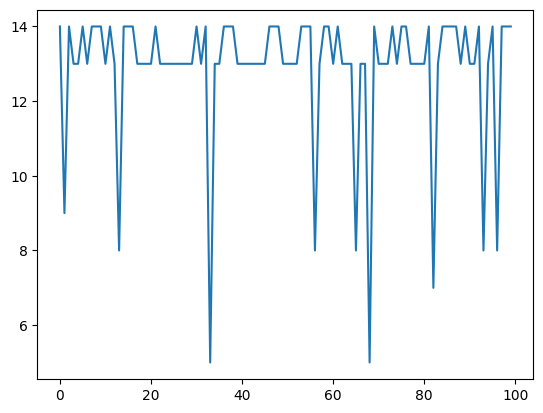

In [51]:
import matplotlib.pyplot as plt
plt.plot(order_book_tomatoes['spread'][0:100])


In [53]:
order_book_tomatoes['spread'].value_counts()


spread
13    9603
14    8954
8      466
7      408
6      253
5      184
9      132
Name: count, dtype: int64

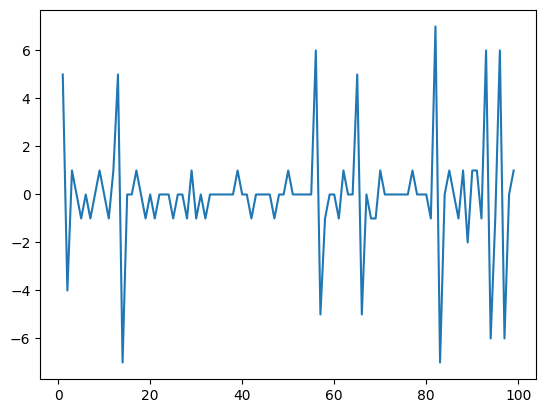

In [46]:
import matplotlib.pyplot as plt
plt.plot(order_book_tomatoes['bid_diff'][0:100])

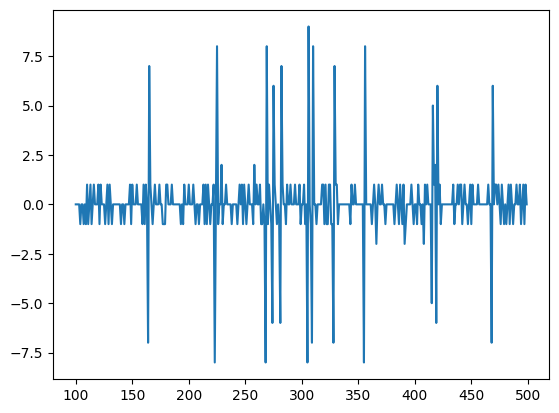

In [40]:
plt.plot(order_book_tomatoes['ask_diff'][100:500])

In [17]:
import csv
import json
json_file = None
with open("logs/26716.log", "r") as f:
    json_file = json.load(f)
    
json_file.keys()

dict_keys(['submissionId', 'activitiesLog', 'logs', 'tradeHistory'])

In [18]:
json_file['tradeHistory']

[{'timestamp': 2900,
  'buyer': 'SUBMISSION',
  'seller': '',
  'symbol': 'TOMATOES',
  'currency': 'XIRECS',
  'price': 4998.0,
  'quantity': 3},
 {'timestamp': 3300,
  'buyer': 'SUBMISSION',
  'seller': '',
  'symbol': 'TOMATOES',
  'currency': 'XIRECS',
  'price': 4997.0,
  'quantity': 3},
 {'timestamp': 3900,
  'buyer': '',
  'seller': 'SUBMISSION',
  'symbol': 'TOMATOES',
  'currency': 'XIRECS',
  'price': 5002.0,
  'quantity': 8},
 {'timestamp': 4200,
  'buyer': 'SUBMISSION',
  'seller': '',
  'symbol': 'TOMATOES',
  'currency': 'XIRECS',
  'price': 5001.0,
  'quantity': 7},
 {'timestamp': 5900,
  'buyer': '',
  'seller': 'SUBMISSION',
  'symbol': 'EMERALDS',
  'currency': 'XIRECS',
  'price': 10007.0,
  'quantity': 8},
 {'timestamp': 9100,
  'buyer': 'SUBMISSION',
  'seller': '',
  'symbol': 'EMERALDS',
  'currency': 'XIRECS',
  'price': 10000.0,
  'quantity': 7},
 {'timestamp': 9700,
  'buyer': 'SUBMISSION',
  'seller': '',
  'symbol': 'EMERALDS',
  'currency': 'XIRECS',
  'pri

In [20]:
json_file['activitiesLog']

'day;timestamp;product;bid_price_1;bid_volume_1;bid_price_2;bid_volume_2;bid_price_3;bid_volume_3;ask_price_1;ask_volume_1;ask_price_2;ask_volume_2;ask_price_3;ask_volume_3;mid_price;profit_and_loss\n-1;0;TOMATOES;4999;6;4998;19;;;5013;6;5014;19;;;5006.0;0.0\n-1;0;EMERALDS;9992;15;9990;30;;;10008;15;10010;30;;;10000.0;0.0\n-1;100;EMERALDS;9992;13;9990;30;;;10008;13;10010;30;;;10000.0;0.0\n-1;100;TOMATOES;5000;5;4998;23;;;5013;5;5014;23;;;5006.5;0.0\n-1;200;EMERALDS;9992;13;9990;21;;;10008;13;10010;21;;;10000.0;0.0\n-1;200;TOMATOES;5000;10;4999;20;;;5013;10;5015;20;;;5006.5;0.0\n-1;300;TOMATOES;5000;9;4999;24;;;5014;9;5015;24;;;5007.0;0.0\n-1;300;EMERALDS;9992;11;9990;23;;;10008;11;10010;23;;;10000.0;0.0\n-1;400;TOMATOES;5000;6;4999;25;;;5014;6;5015;25;;;5007.0;0.0\n-1;400;EMERALDS;9992;13;9990;23;;;10008;13;10010;23;;;10000.0;0.0\n-1;500;EMERALDS;9992;12;9990;22;;;10008;12;10010;22;;;10000.0;0.0\n-1;500;TOMATOES;5000;6;4999;25;;;5014;6;5015;25;;;5007.0;0.0\n-1;600;EMERALDS;9992;12;9990

In [21]:
from io import StringIO
df = pd.read_csv(StringIO(json_file['activitiesLog']), delimiter = ';')

In [22]:
df.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,TOMATOES,4999,6,4998,19,NaN,NaN,5013,6,5014,19,NaN,NaN,5006.0,0.0
1,-1,0,EMERALDS,9992,15,9990,30,NaN,NaN,10008,15,10010,30,NaN,NaN,10000.0,0.0
2,-1,100,EMERALDS,9992,13,9990,30,NaN,NaN,10008,13,10010,30,NaN,NaN,10000.0,0.0
3,-1,100,TOMATOES,5000,5,4998,23,NaN,NaN,5013,5,5014,23,NaN,NaN,5006.5,0.0
4,-1,200,EMERALDS,9992,13,9990,21,NaN,NaN,10008,13,10010,21,NaN,NaN,10000.0,0.0


In [23]:
import pandas as pd

# order book dataframe
# df columns include: timestamp, product, ...

# trades is a list of dicts
trades_df = pd.DataFrame(json_file['tradeHistory'])

# keep only your own trades
# buy by SUBMISSION => positive
# sell by SUBMISSION => negative
trades_df["signed_qty"] = 0
trades_df.loc[trades_df["buyer"] == "SUBMISSION", "signed_qty"] += trades_df["quantity"]
trades_df.loc[trades_df["seller"] == "SUBMISSION", "signed_qty"] -= trades_df["quantity"]

# aggregate net trade quantity per timestamp and product
pos_changes = (
    trades_df.groupby(["timestamp", "symbol"], as_index=False)["signed_qty"]
    .sum()
    .rename(columns={"symbol": "product"})
)

# merge into order book df
df = df.merge(pos_changes, on=["timestamp", "product"], how="left")

# fill missing with 0, then cumulative sum by product
df["signed_qty"] = df["signed_qty"].fillna(0)
df["position"] = df.groupby("product")["signed_qty"].cumsum()

# optional: drop helper column
df = df.drop(columns=["signed_qty"])

In [24]:
df.head(100)

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,position
0,-1,0,TOMATOES,4999,6,4998,19,NaN,NaN,5013,6,5014,19,NaN,NaN,5006.0,0.000000,0.0
1,-1,0,EMERALDS,9992,15,9990,30,NaN,NaN,10008,15,10010,30,NaN,NaN,10000.0,0.000000,0.0
2,-1,100,EMERALDS,9992,13,9990,30,NaN,NaN,10008,13,10010,30,NaN,NaN,10000.0,0.000000,0.0
3,-1,100,TOMATOES,5000,5,4998,23,NaN,NaN,5013,5,5014,23,NaN,NaN,5006.5,0.000000,0.0
4,-1,200,EMERALDS,9992,13,9990,21,NaN,NaN,10008,13,10010,21,NaN,NaN,10000.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,-1,4700,EMERALDS,9992,10,9990,26,NaN,NaN,10008,10,10010,26,NaN,NaN,10000.0,0.000000,0.0
96,-1,4800,EMERALDS,9992,13,9990,24,NaN,NaN,10008,13,10010,24,NaN,NaN,10000.0,0.000000,0.0
97,-1,4800,TOMATOES,4995,7,4994,21,NaN,NaN,5009,7,5010,21,NaN,NaN,5002.0,33.269531,5.0
98,-1,4900,TOMATOES,4995,10,4994,16,NaN,NaN,5009,10,5010,16,NaN,NaN,5002.0,33.593750,5.0


In [25]:
import pandas as pd
import plotly.graph_objects as go

def plot_orderbook_and_trades(df, trades, product=None):
    df_plot = df.copy()

    if product is not None:
        df_plot = df_plot[df_plot["product"] == product].copy()

    df_plot = df_plot.sort_values("timestamp")

    trades_df = pd.DataFrame(trades)
    if trades_df.empty:
        trades_df = pd.DataFrame(columns=["timestamp", "buyer", "seller", "symbol", "price", "quantity"])

    if product is not None and not trades_df.empty:
        trades_df = trades_df[trades_df["symbol"] == product].copy()

    if not trades_df.empty:
        trades_df = trades_df.sort_values("timestamp")

        def trade_side(row):
            if row.get("buyer") == "SUBMISSION":
                return "BUY"
            elif row.get("seller") == "SUBMISSION":
                return "SELL"
            return "OTHER"

        trades_df["side"] = trades_df.apply(trade_side, axis=1)

    fig = go.Figure()

    # --- bid prices ---
    for col in ["bid_price_1", "bid_price_2", "bid_price_3"]:
        if col in df_plot.columns:
            fig.add_trace(
                go.Scatter(
                    x=df_plot["timestamp"],
                    y=df_plot[col],
                    mode="lines+markers",
                    name=col,
                    connectgaps=False,
                    hovertemplate=f"timestamp=%{{x}}<br>{col}=%{{y}}<extra>{col}</extra>"
                )
            )

    # --- ask prices ---
    for col in ["ask_price_1", "ask_price_2", "ask_price_3"]:
        if col in df_plot.columns:
            fig.add_trace(
                go.Scatter(
                    x=df_plot["timestamp"],
                    y=df_plot[col],
                    mode="lines+markers",
                    name=col,
                    connectgaps=False,
                    hovertemplate=f"timestamp=%{{x}}<br>{col}=%{{y}}<extra>{col}</extra>"
                )
            )

    # --- mid price ---
    if "mid_price" in df_plot.columns:
        fig.add_trace(
            go.Scatter(
                x=df_plot["timestamp"],
                y=df_plot["mid_price"],
                mode="lines",
                name="mid_price",
                hovertemplate="timestamp=%{x}<br>mid_price=%{y}<extra>mid_price</extra>"
            )
        )

    # --- profit and loss ---
    if "profit_and_loss" in df_plot.columns:
        fig.add_trace(
            go.Scatter(
                x=df_plot["timestamp"],
                y=df_plot["profit_and_loss"],
                mode="lines",
                name="profit_and_loss",
                yaxis="y2",
                hovertemplate="timestamp=%{x}<br>profit_and_loss=%{y}<extra>profit_and_loss</extra>"
            )
        )

    # --- position ---
    if "position" in df_plot.columns:
        fig.add_trace(
            go.Scatter(
                x=df_plot["timestamp"],
                y=df_plot["position"],
                mode="lines",
                name="position",
                yaxis="y2",
                hovertemplate="timestamp=%{x}<br>position=%{y}<extra>position</extra>"
            )
        )

    # --- trades ---
    if not trades_df.empty:
        side_to_symbol = {
            "BUY": "triangle-up",
            "SELL": "triangle-down",
            "OTHER": "circle"
        }

        side_to_color = {
            "BUY": None,
            "SELL": None,
            "OTHER": "red"
        }

        for side in ["BUY", "SELL", "OTHER"]:
            curr = trades_df[trades_df["side"] == side]
            if curr.empty:
                continue

            marker_dict = {
                "symbol": side_to_symbol[side],
                "size": 14
            }

            if side_to_color[side] is not None:
                marker_dict["color"] = side_to_color[side]

            fig.add_trace(
                go.Scatter(
                    x=curr["timestamp"],
                    y=curr["price"],
                    mode="markers",
                    name=f"trades_{side.lower()}",
                    marker=marker_dict,
                    customdata=curr[["quantity", "buyer", "seller", "symbol"]].values,
                    hovertemplate=(
                        "timestamp=%{x}<br>"
                        "price=%{y}<br>"
                        "qty=%{customdata[0]}<br>"
                        "buyer=%{customdata[1]}<br>"
                        "seller=%{customdata[2]}<br>"
                        "symbol=%{customdata[3]}"
                        "<extra>" + side + "</extra>"
                    )
                )
            )

    title = "Order Book and Trades"
    if product is not None:
        title += f" - {product}"

    fig.update_layout(
        title=title,
        xaxis_title="timestamp",
        yaxis_title="price",
        yaxis2=dict(
            title="position / profit_and_loss",
            overlaying="y",
            side="right"
        ),
        hovermode="x unified",
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="left",
            x=0
        )
    )

    return fig

In [26]:
fig = plot_orderbook_and_trades(df, json_file['tradeHistory'], product="TOMATOES")
fig.show(renderer="browser")

In [29]:
import csv
import json
import pandas as pd
from io import StringIO
import pandas as pd
import plotly.graph_objects as go


def plot(log_filepath):

    json_file = None
    with open(log_filepath, "r") as f:
        json_file = json.load(f)
        

    df = pd.read_csv(StringIO(json_file['activitiesLog']), delimiter = ';')


    # order book dataframe
    # df columns include: timestamp, product, ...

    # trades is a list of dicts
    trades_df = pd.DataFrame(json_file['tradeHistory'])

    # keep only your own trades
    # buy by SUBMISSION => positive
    # sell by SUBMISSION => negative
    trades_df["signed_qty"] = 0
    trades_df.loc[trades_df["buyer"] == "SUBMISSION", "signed_qty"] += trades_df["quantity"]
    trades_df.loc[trades_df["seller"] == "SUBMISSION", "signed_qty"] -= trades_df["quantity"]

    # aggregate net trade quantity per timestamp and product
    pos_changes = (
        trades_df.groupby(["timestamp", "symbol"], as_index=False)["signed_qty"]
        .sum()
        .rename(columns={"symbol": "product"})
    )

    # merge into order book df
    df = df.merge(pos_changes, on=["timestamp", "product"], how="left")

    # fill missing with 0, then cumulative sum by product
    df["signed_qty"] = df["signed_qty"].fillna(0)
    df["position"] = df.groupby("product")["signed_qty"].cumsum()

    # optional: drop helper column
    df = df.drop(columns=["signed_qty"])

    
    def plot_orderbook_and_trades(df, trades, product=None):
        df_plot = df.copy()

        if product is not None:
            df_plot = df_plot[df_plot["product"] == product].copy()

        df_plot = df_plot.sort_values("timestamp")

        trades_df = pd.DataFrame(trades)
        if trades_df.empty:
            trades_df = pd.DataFrame(columns=["timestamp", "buyer", "seller", "symbol", "price", "quantity"])

        if product is not None and not trades_df.empty:
            trades_df = trades_df[trades_df["symbol"] == product].copy()

        if not trades_df.empty:
            trades_df = trades_df.sort_values("timestamp")

            def trade_side(row):
                if row.get("buyer") == "SUBMISSION":
                    return "BUY"
                elif row.get("seller") == "SUBMISSION":
                    return "SELL"
                return "OTHER"

            trades_df["side"] = trades_df.apply(trade_side, axis=1)

        fig = go.Figure()

        # --- bid prices ---
        for col in ["bid_price_1", "bid_price_2", "bid_price_3"]:
            if col in df_plot.columns:
                fig.add_trace(
                    go.Scatter(
                        x=df_plot["timestamp"],
                        y=df_plot[col],
                        mode="lines+markers",
                        name=col,
                        connectgaps=False,
                        hovertemplate=f"timestamp=%{{x}}<br>{col}=%{{y}}<extra>{col}</extra>"
                    )
                )

        # --- ask prices ---
        for col in ["ask_price_1", "ask_price_2", "ask_price_3"]:
            if col in df_plot.columns:
                fig.add_trace(
                    go.Scatter(
                        x=df_plot["timestamp"],
                        y=df_plot[col],
                        mode="lines+markers",
                        name=col,
                        connectgaps=False,
                        hovertemplate=f"timestamp=%{{x}}<br>{col}=%{{y}}<extra>{col}</extra>"
                    )
                )

        # --- mid price ---
        if "mid_price" in df_plot.columns:
            fig.add_trace(
                go.Scatter(
                    x=df_plot["timestamp"],
                    y=df_plot["mid_price"],
                    mode="lines",
                    name="mid_price",
                    hovertemplate="timestamp=%{x}<br>mid_price=%{y}<extra>mid_price</extra>"
                )
            )

        # --- profit and loss ---
        if "profit_and_loss" in df_plot.columns:
            fig.add_trace(
                go.Scatter(
                    x=df_plot["timestamp"],
                    y=df_plot["profit_and_loss"],
                    mode="lines",
                    name="profit_and_loss",
                    yaxis="y2",
                    hovertemplate="timestamp=%{x}<br>profit_and_loss=%{y}<extra>profit_and_loss</extra>"
                )
            )

        # --- position ---
        if "position" in df_plot.columns:
            fig.add_trace(
                go.Scatter(
                    x=df_plot["timestamp"],
                    y=df_plot["position"],
                    mode="lines",
                    name="position",
                    yaxis="y2",
                    hovertemplate="timestamp=%{x}<br>position=%{y}<extra>position</extra>"
                )
            )

        # --- trades ---
        if not trades_df.empty:
            side_to_symbol = {
                "BUY": "triangle-up",
                "SELL": "triangle-down",
                "OTHER": "circle"
            }

            side_to_color = {
                "BUY": None,
                "SELL": None,
                "OTHER": "red"
            }

            for side in ["BUY", "SELL", "OTHER"]:
                curr = trades_df[trades_df["side"] == side]
                if curr.empty:
                    continue

                marker_dict = {
                    "symbol": side_to_symbol[side],
                    "size": 14
                }

                if side_to_color[side] is not None:
                    marker_dict["color"] = side_to_color[side]

                fig.add_trace(
                    go.Scatter(
                        x=curr["timestamp"],
                        y=curr["price"],
                        mode="markers",
                        name=f"trades_{side.lower()}",
                        marker=marker_dict,
                        customdata=curr[["quantity", "buyer", "seller", "symbol"]].values,
                        hovertemplate=(
                            "timestamp=%{x}<br>"
                            "price=%{y}<br>"
                            "qty=%{customdata[0]}<br>"
                            "buyer=%{customdata[1]}<br>"
                            "seller=%{customdata[2]}<br>"
                            "symbol=%{customdata[3]}"
                            "<extra>" + side + "</extra>"
                        )
                    )
                )

        title = "Order Book and Trades"
        if product is not None:
            title += f" - {product}"

        fig.update_layout(
            title=title,
            xaxis_title="timestamp",
            yaxis_title="price",
            yaxis2=dict(
                title="position / profit_and_loss",
                overlaying="y",
                side="right"
            ),
            hovermode="x unified",
            legend=dict(
                orientation="h",
                yanchor="bottom",
                y=1.02,
                xanchor="left",
                x=0
            )
        )

        return fig


    fig = plot_orderbook_and_trades(df, json_file['tradeHistory'], product="TOMATOES")
    fig.show(renderer="browser")

In [30]:
plot('logs/26859.log')

In [54]:
log_filepath = 'logs/26859.log'

In [55]:
json_file = None
with open(log_filepath, "r") as f:
    json_file = json.load(f)
df = pd.read_csv(StringIO(json_file['activitiesLog']), delimiter = ';')
trades_df = pd.DataFrame(json_file['tradeHistory'])

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,TOMATOES,4999,6,4998,19,NaN,NaN,5013,6,5014,19,NaN,NaN,5006.0,0.0
1,-1,0,EMERALDS,9992,15,9990,30,NaN,NaN,10008,15,10010,30,NaN,NaN,10000.0,0.0
2,-1,100,EMERALDS,9992,13,9990,30,NaN,NaN,10008,13,10010,30,NaN,NaN,10000.0,0.0
3,-1,100,TOMATOES,5000,5,4998,23,NaN,NaN,5013,5,5014,23,NaN,NaN,5006.5,0.0
4,-1,200,EMERALDS,9992,13,9990,21,NaN,NaN,10008,13,10010,21,NaN,NaN,10000.0,0.0


In [61]:
trades_df.head()
trades_df = trades_df[trades_df['symbol'] == 'TOMATOES']

In [63]:
trades_df[trades_df['quantity'] >= 8].head(50)

,timestamp,buyer,seller,symbol,currency,price,quantity
2,3900,,SUBMISSION,TOMATOES,XIRECS,5002.0,8
9,12900,SUBMISSION,,TOMATOES,XIRECS,5003.0,11
15,21400,SUBMISSION,,TOMATOES,XIRECS,4997.0,9
34,42900,,SUBMISSION,TOMATOES,XIRECS,4983.0,12
38,45700,SUBMISSION,,TOMATOES,XIRECS,4982.0,12
43,51500,SUBMISSION,,TOMATOES,XIRECS,4986.0,11
53,59800,SUBMISSION,,TOMATOES,XIRECS,4986.0,11
58,65600,,SUBMISSION,TOMATOES,XIRECS,4990.0,9
59,66200,,SUBMISSION,TOMATOES,XIRECS,4989.0,11
65,70300,,SUBMISSION,TOMATOES,XIRECS,4988.0,8


In [71]:
df[df['bid_price_2'].isna() == True].head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss


In [6]:
from plotter import LogVisualizer

In [7]:
plot = LogVisualizer('logs/32215.log')
plot.visualize()

Parsed 4000 order-book rows | 176 own trades | 1727 market trades | products: ['EMERALDS', 'TOMATOES']


interactive(children=(Dropdown(description='Product:', options=('EMERALDS', 'TOMATOES'), value='EMERALDS'), Ou…

In [5]:
from pathlib import Path

path = Path("logs/32123.log")

if path.exists():
    with open(path) as f:
        data = f.read()
    print('hi')
else:
    print("File does not exist")

hi
